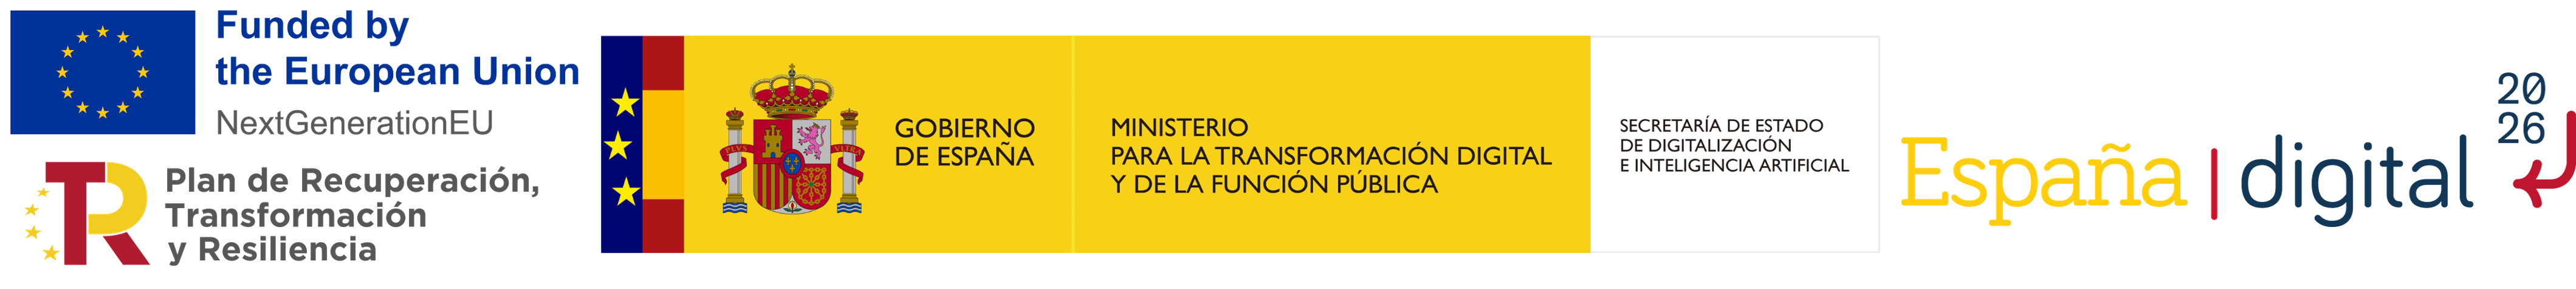

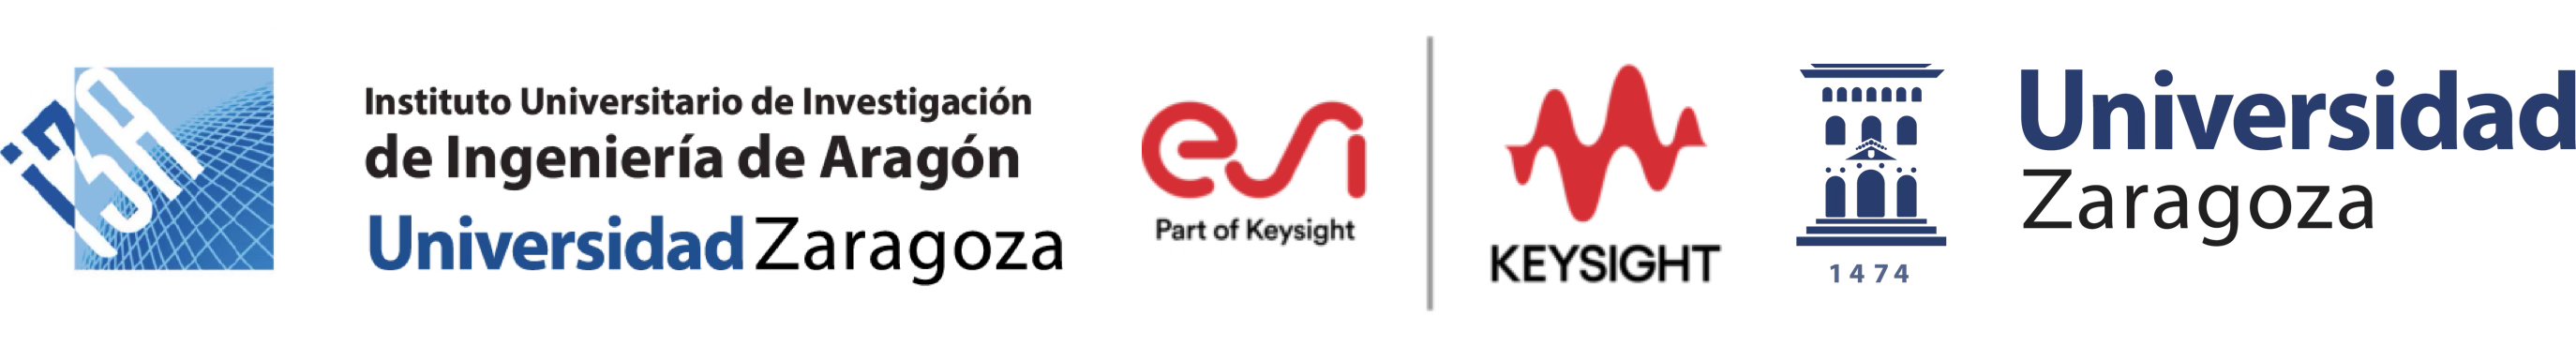

<h1 style="text-align: center; font-family: 'Arial', sans-serif; color: #2c3e50;">
  <strong>Graph Neural Networks - Hands-on session 1</strong>
</h1>

<hr style="border: 1px solid #2c3e50; width: 80%; margin: auto;">

<p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 18px;">
  This notebook introduces an introductory setup for running a GNN from our GitHub to solve an elliptic problem.
</p>

**GitHub**: https://github.com/LucasUnizar/GNN-Workshop

> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 20px;">
  <strong>Lecture</strong><br>
  </p>
  Lucas Tesán
  </p>
  Pau Urdeitx
</p>

> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 20px;">
  <strong>Notebook Author</strong><br>
  </p>
  Lucas Tesán
  </p>
  Pau Urdeitx
</p>

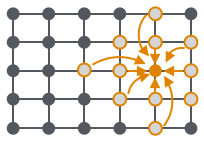


# 🌟 GNNs-Lightning Setup  
### 🛠️ *Environment Configuration & Repository Installation*  

**GitHub Repository:**
---

This section handles all the groundwork—cloning the GitHub repository, installing required libraries, and configuring the environment—so your notebook runs smoothly. Simply execute the cells below to get everything ready!



In [1]:
!git clone --filter=blob:none --sparse https://github.com/ESI-UZ-Chair/HoB-Scientific-Artificial-Intelligence-Programming.git

%cd HoB-Scientific-Artificial-Intelligence-Programming

!git sparse-checkout set chapter08/GNN-main

%cd chapter08/GNN-main

Cloning into 'HoB-Scientific-Artificial-Intelligence-Programming'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 125 (delta 12), reused 65 (delta 12), pack-reused 57 (from 1)
Receiving objects: 100% (125/125), 71.45 KiB | 332.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.
remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 2 (delta 0), reused 0 (delta 0), pack-reused 1 (from 1)
Receiving objects: 100% (2/2), 12.11 KiB | 177.00 KiB/s, done.
/Users/usuario/Desktop/Documentos/Cursos/Jaca25/HoB-Scientific-Artificial-Intelligence-Programming/chapter08/colabs/HoB-Scientific-Artificial-Intelligence-Programming
remote: Enumerating objects: 2375, done.
remote: Counting objects: 100% (2374/2374), done.
remote: Compressing objects: 100% (192/192), done.pressing objects:  96% (185/192)
remote: Total 2375 (delta 2183), reused 2370 (delta 2182), 

In [2]:
!pip install -r requirements.txt --quiet

# **1. Data Visualization**

In this section, we will visualize each dataset to better understand the types of data we are working with, enhancing overall clarity and insight.

## Elliptic Poisson problem

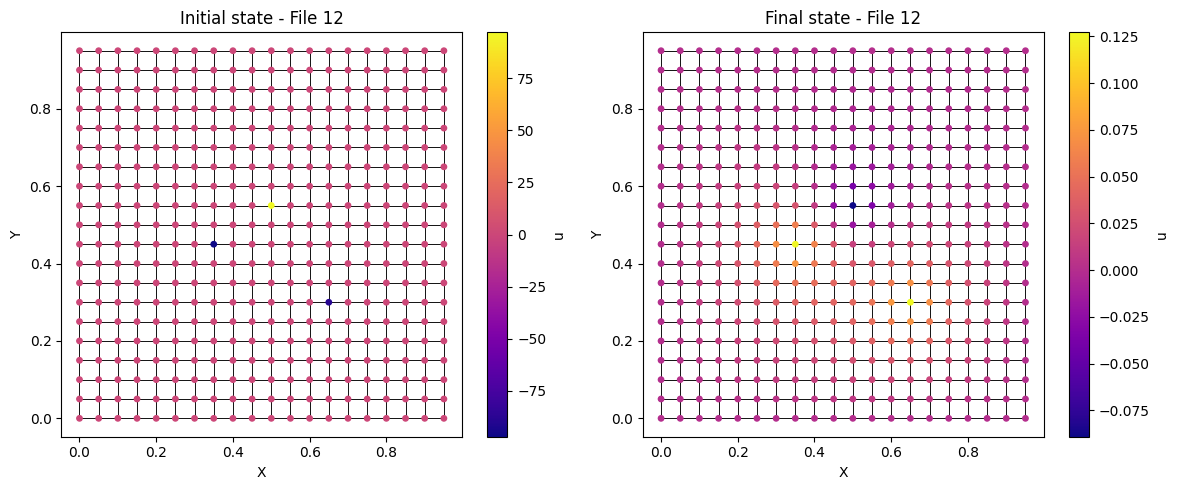

In [3]:
from src.dataloader.datamodule import GraphDataModule

# Data preparatio
data_module = GraphDataModule(dataset_dir='data/Jaca-SummerSchool25_Elliptic_HighRes/dataset', batch_size=8, ratio=1., dataset_type='poisson')
# Setup the data module (this loads the datasets)
data_module.setup(stage='fit')

# Visualize a single sample from the training set
data_module.plot_first_and_last_rollout(traj_index=12)

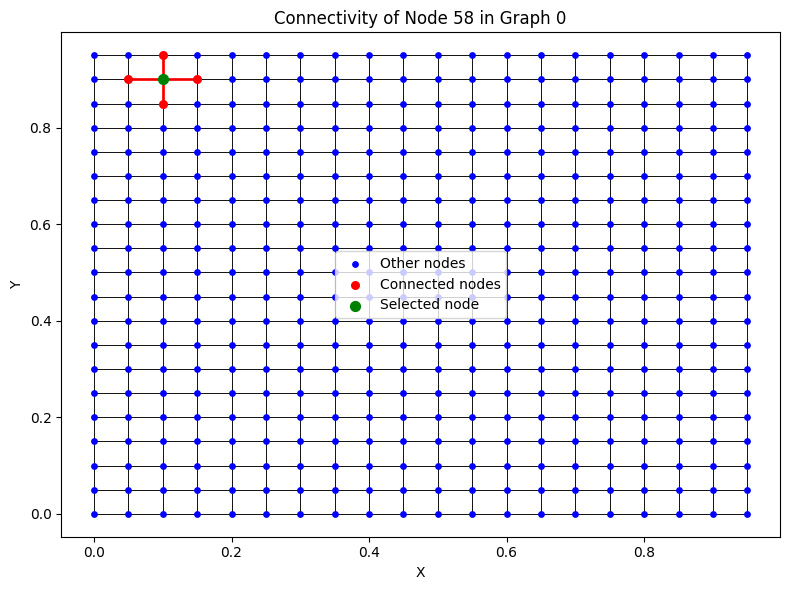

In [4]:
data_module.plot_node_connectivity(traj_index=0, node_index=58)

# **2. Solving the Poisson Equation with Graph Neural Networks**  

In this section, we use **Graph Neural Networks (GNNs)** to solve the **Poisson equation**, an elliptic PDE with applications in electrostatics, fluid mechanics, and more. Traditional numerical methods (e.g., finite differences) are replaced with a **data-driven, single-step prediction** approach.

## **Mathematical Formulation**  
The Poisson equation is defined as:  

$$
\nabla^2 u = f \quad \text{in} \ \Omega
$$

with boundary conditions:  

$$
u = 0 \quad \text{on} \ \partial \Omega
$$

where:
- $u$: Unknown solution (e.g., electric potential),  
- $f$: Known source term (e.g., charge distribution),  
- $\nabla^2$: Laplacian operator,  
- $\Omega$: Spatial domain,  
- $ \partial \Omega $: Domain boundary.

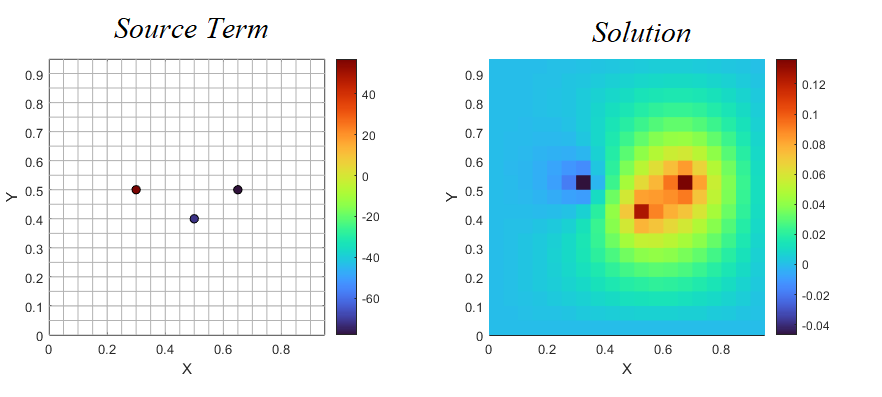

In [5]:
# model hyperparameters configuration
CONFIG={
    'model':'poisson',
    'run_name':'test1',
    'dataset_dir': 'data/Jaca-SummerSchool25_Elliptic_HighRes/dataset',
    'hidden': 16,
    'layers': 2,
    'mp_steps': 1,
    'batch_size': 64,
    'lr': 1.e-3,
    'epochs': 10,
    'eval_freq': 10,
}

# training launcher
!python train.py --dataset_dir {CONFIG['dataset_dir']} --model {CONFIG['model']} --hidden {CONFIG['hidden']} --layers {CONFIG['layers']} --mp_steps {CONFIG['mp_steps']} --batch_size {CONFIG['batch_size']} --lr {CONFIG['lr']} --epochs {CONFIG['epochs']} --eval_freq {CONFIG['eval_freq']}


Seed set to 1
Simulator model initialized
Using 1-Step GNN model with 1 message-passing steps
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/usuario/miniconda3/envs/Jaca26/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/usuario/.netrc.
wandb: Currently logged in as: lucastes to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 62kjb22o (0.0s)
wandb: ⣻ setting up run 62kjb22o (0.0s)
wandb: ⣽ setting up run 62kjb2

In [6]:
from pathlib import Path
from IPython.display import Image, display

RUN_DIR = "2026-07-06_19-52-34_MPSteps=1_sharedMP=False_layers=2_hidden=16_batchsize=64_seed=1"
CKPT = f"outputs/runs/{RUN_DIR}/models/topk1.pth"
PLT = f"outputs/runs/{RUN_DIR}"

!python rollout.py \
  --model poisson \
  --dataset_dir data/Jaca-SummerSchool25_Elliptic_HighRes/dataset \
  --split test \
  --pretrain_path "$CKPT"

run_dir = Path(PLT)

for f in run_dir.rglob("*"):
    if f.suffix.lower() in [".png", ".jpg", ".jpeg"]:
        print(f)
        display(Image(filename=str(f)))


Seed set to 42
Traceback (most recent call last):
  File "/Users/usuario/Desktop/Documentos/Cursos/Jaca25/HoB-Scientific-Artificial-Intelligence-Programming/chapter08/colabs/HoB-Scientific-Artificial-Intelligence-Programming/chapter08/GNN-main/rollout.py", line 39, in <module>
    simulator = SimulatorGNN(pretrain=pretrain_path, device='cpu', mssg_flag=args.mssg_flag)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/usuario/Desktop/Documentos/Cursos/Jaca25/HoB-Scientific-Artificial-Intelligence-Programming/chapter08/colabs/HoB-Scientific-Artificial-Intelligence-Programming/chapter08/GNN-main/src/model/model.py", line 29, in __init__
    with open(json_path, "r") as file:
         ^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'outputs/runs/2026-07-06_19-52-34_MPSteps=1_sharedMP=False_layers=2_hidden=16_batchsize=64_seed=1/config.json'
